In [3]:
print("hello")

hello


In [4]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score


In [6]:
path="C:\\Users\\CANSU\\Desktop\\ML\\NASA TURBOFAN DATASET\\train_FD001.txt"
df=pd.read_csv(path,sep=" ")

In [7]:
df.head()


,1,1.1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.00,39.06,23.4190,Unnamed: 26,Unnamed: 27
0,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,NaN,NaN
1,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,NaN,NaN
2,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,NaN,NaN
3,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,NaN,NaN
4,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669,NaN,NaN


In [8]:
df.shape

(20630, 28)

In [9]:
df.columns

Index(['1', '1.1', '-0.0007', '-0.0004', '100.0', '518.67', '641.82',
       '1589.70', '1400.60', '14.62', '21.61', '554.36', '2388.06', '9046.19',
       '1.30', '47.47', '521.66', '2388.02', '8138.62', '8.4195', '0.03',
       '392', '2388', '100.00', '39.06', '23.4190', 'Unnamed: 26',
       'Unnamed: 27'],
      dtype='str')

In [10]:
df.drop(['Unnamed: 27','Unnamed: 26'],axis=1,inplace=True) # I am dropping features that has just NaN value

In [11]:
df.columns

Index(['1', '1.1', '-0.0007', '-0.0004', '100.0', '518.67', '641.82',
       '1589.70', '1400.60', '14.62', '21.61', '554.36', '2388.06', '9046.19',
       '1.30', '47.47', '521.66', '2388.02', '8138.62', '8.4195', '0.03',
       '392', '2388', '100.00', '39.06', '23.4190'],
      dtype='str')

In [14]:
columns_name=["unit_number","time_in_cycles","os_1","os_2","os_3"]
for i in range(1,22):
    columns_name.append(f"s_{i}")
columns_name

['unit_number',
 'time_in_cycles',
 'os_1',
 'os_2',
 'os_3',
 's_1',
 's_2',
 's_3',
 's_4',
 's_5',
 's_6',
 's_7',
 's_8',
 's_9',
 's_10',
 's_11',
 's_12',
 's_13',
 's_14',
 's_15',
 's_16',
 's_17',
 's_18',
 's_19',
 's_20',
 's_21']

In [15]:
df.columns=columns_name
df.head()

,unit_number,time_in_cycles,os_1,os_2,os_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
1,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
2,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
3,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
4,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,521.68,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669


In [22]:
df.isna().sum()

unit_number       0
time_in_cycles    0
os_1              0
os_2              0
os_3              0
s_1               0
s_2               0
s_3               0
s_4               0
s_5               0
s_6               0
s_7               0
s_8               0
s_9               0
s_10              0
s_11              0
s_12              0
s_13              0
s_14              0
s_15              0
s_16              0
s_17              0
s_18              0
s_19              0
s_20              0
s_21              0
dtype: int64

In [25]:
for col in df.columns:
    print(df[col].value_counts())


unit_number
69    362
92    341
96    336
67    313
83    293
     ... 
58    147
57    137
70    137
91    135
39    128
Name: count, Length: 100, dtype: int64
time_in_cycles
2      100
3      100
4      100
5      100
6      100
      ... 
358      1
359      1
360      1
361      1
362      1
Name: count, Length: 362, dtype: int64
os_1
 0.0000    413
 0.0002    398
 0.0004    394
-0.0005    390
 0.0001    382
          ... 
-0.0075      1
 0.0087      1
-0.0087      1
-0.0078      1
 0.0077      1
Name: count, Length: 158, dtype: int64
os_2
-0.0003    2104
 0.0001    2097
 0.0000    2070
 0.0003    2065
-0.0004    2050
-0.0002    2049
 0.0002    2038
-0.0001    2029
 0.0004    1997
 0.0005    1068
-0.0005     958
 0.0006      71
-0.0006      34
Name: count, dtype: int64
os_3
100.0    20630
Name: count, dtype: int64
s_1
518.67    20630
Name: count, dtype: int64
s_2
642.50    190
642.56    189
642.53    188
642.60    184
642.67    179
         ... 
641.21      1
644.31      1
644.34  

In [28]:
df.drop(["os_3","s_1","s_5","s_10","s_16","s_18","s_19"],axis=1,inplace=True)#These features have only one value.For this reason I dropped them. Because there aren't information gain for any ML models. Their variance is zero.

In [29]:
df.shape

(20630, 19)

In [30]:
df

,unit_number,time_in_cycles,os_1,os_2,s_2,s_3,s_4,s_6,s_7,s_8,s_9,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21
0,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236
1,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442
2,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739
3,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044
4,1,6,-0.0043,-0.0001,642.10,1584.47,1398.37,21.61,554.67,2388.02,9049.68,47.16,521.68,2388.03,8132.85,8.4108,391,38.98,23.3669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20625,100,196,-0.0004,-0.0003,643.49,1597.98,1428.63,21.61,551.43,2388.19,9065.52,48.07,519.49,2388.26,8137.60,8.4956,397,38.49,22.9735
20626,100,197,-0.0016,-0.0005,643.54,1604.50,1433.58,21.61,550.86,2388.23,9065.11,48.04,519.68,2388.22,8136.50,8.5139,395,38.30,23.1594
20627,100,198,0.0004,0.0000,643.42,1602.46,1428.18,21.61,550.94,2388.24,9065.90,48.09,520.01,2388.24,8141.05,8.5646,398,38.44,22.9333
20628,100,199,-0.0011,0.0003,643.23,1605.26,1426.53,21.61,550.68,2388.25,9073.72,48.39,519.67,2388.23,8139.29,8.5389,395,38.29,23.0640


<Axes: xlabel='unit_number', ylabel='Count'>

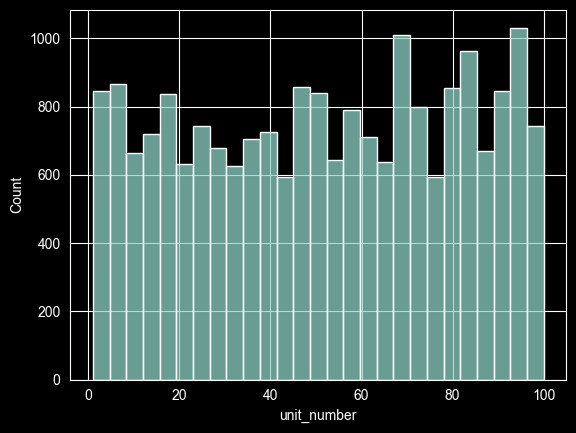